**1. Given a small dataset of 6 food delivery orders (with features like delivery_time and distance),
manually create the initial distance matrix using the Euclidean distance formula between
each pair of orders.<br><br><em><strong>Hint:</strong> Use the formula sqrt((x2 - x1)^2 + (y2 - y1)^2) 
for each pair.</em>**

In [1]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

In [3]:
orders = pd.DataFrame({
    'Order':['O1','O2','O3','O4','O5','O6'],
    'Delivery_Time':[20,25,30,35,40,45],
    'Distance':[2,3,5,6,8,9]
})

print(orders)

  Order  Delivery_Time  Distance
0    O1             20         2
1    O2             25         3
2    O3             30         5
3    O4             35         6
4    O5             40         8
5    O6             45         9


In [7]:
X = orders[['Delivery_Time','Distance']]

distance_matrix = squareform(pdist(X, metric='euclidean'))

distance_df = pd.DataFrame(
    distance_matrix,
    index=orders['Order'],
    columns=orders['Order']
)

print(distance_df)

Order         O1         O2         O3         O4         O5         O6
Order                                                                  
O1      0.000000   5.099020  10.440307  15.524175  20.880613  25.961510
O2      5.099020   0.000000   5.385165  10.440307  15.811388  20.880613
O3     10.440307   5.385165   0.000000   5.099020  10.440307  15.524175
O4     15.524175  10.440307   5.099020   0.000000   5.385165  10.440307
O5     20.880613  15.811388  10.440307   5.385165   0.000000   5.099020
O6     25.961510  20.880613  15.524175  10.440307   5.099020   0.000000


**2. Using Python and sklearn, perform agglomerative hierarchical clustering on a dataset of 8 songs 
(with features like tempo and energy), and plot the resulting dendrogram using scipy's dendrogram function.**

In [11]:
songs = pd.DataFrame({
    'Song':['S1','S2','S3','S4','S5','S6','S7','S8'],
    'Tempo':[90,95,100,105,130,135,140,145],
    'Energy':[40,45,50,55,80,82,90,95]
})

songs

,Song,Tempo,Energy
0,S1,90,40
1,S2,95,45
2,S3,100,50
3,S4,105,55
4,S5,130,80
5,S6,135,82
6,S7,140,90
7,S8,145,95


In [14]:
from sklearn.cluster import AgglomerativeClustering

X = songs[['Tempo','Energy']]
model = AgglomerativeClustering(
    n_clusters=3,
    linkage='single'
)

labels = model.fit_predict(X)
songs['Cluster'] = labels
print(songs)

  Song  Tempo  Energy  Cluster
0   S1     90      40        1
1   S2     95      45        1
2   S3    100      50        1
3   S4    105      55        1
4   S5    130      80        2
5   S6    135      82        2
6   S7    140      90        0
7   S8    145      95        0


In [17]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

**3. Change the linkage method in your clustering code from 'single' to 'complete' and 'average', and 
observe how the dendrogram structure changes for your songs dataset.<br><br><em><strong>
Hint:</strong> Use the linkage parameter in AgglomerativeClustering or scipy's linkage function.</em>**

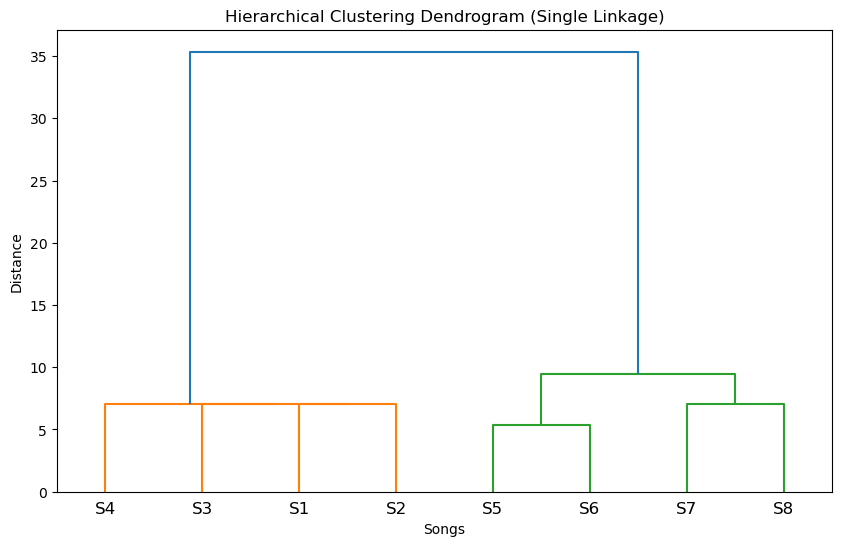

In [19]:
Z = linkage(X, method='single')
plt.figure(figsize=(10,6))

dendrogram(
    Z,
    labels=songs['Song'].values
)

plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
plt.xlabel("Songs")
plt.ylabel("Distance")
plt.show()

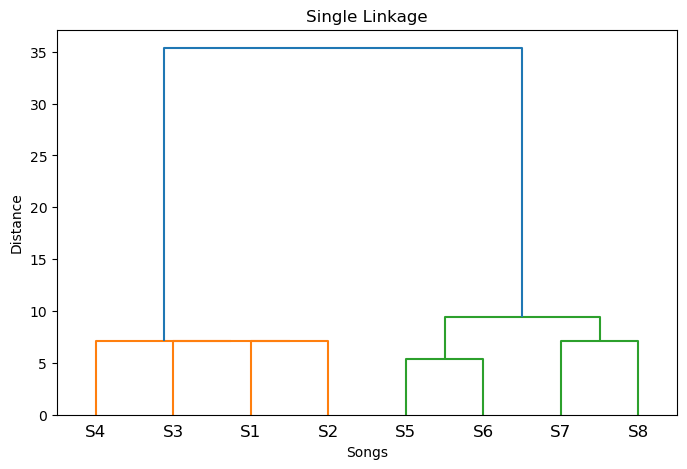

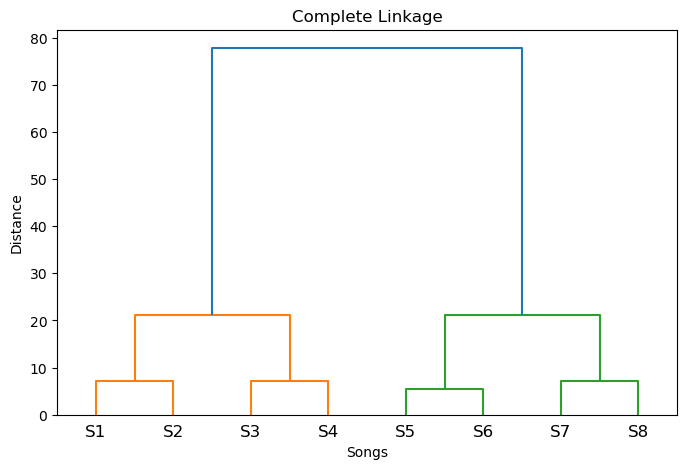

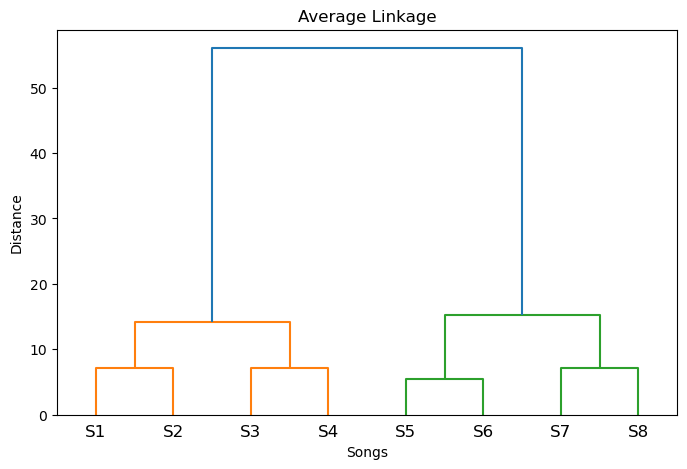

In [23]:
methods = ['single','complete','average']

for method in methods:
    plt.figure(figsize=(8,5))
    Z = linkage(X, method=method)
    dendrogram(
        Z,
        labels=songs['Song'].values
    )

    plt.title(f"{method.capitalize()} Linkage")
    plt.xlabel("Songs")
    plt.ylabel("Distance")
    plt.show()

**Observation**  
**-->Single linkage: Creates long chain-like clusters and is sensitive to noise.**   
**-->Complete linkage: Produces compact and well-separated clusters.**  
**-->Average linkage: Gives balanced clusters and is less affected by outliers than single linkage.**  

**4. 
Write a function that, given two points (x1, y1) and (x2, y2), returns both their Euclidean and
 Manhattan distances. Test it on three pairs of coordinates from your datase**t.y.

In [29]:
import math

def calculate_distance(x1, y1, x2, y2):
    euclidean = math.sqrt((x2-x1)**2 + (y2-y1)**2)
    manhattan = abs(x2-x1) + abs(y2-y1)
    return euclidean, manhattan

In [33]:
pairs = [
    ((20,2),(25,3)),
    ((30,5),(40,8)),
    ((35,6),(45,9))
]

for p1,p2 in pairs:
    e,m = calculate_distance(
        p1[0],p1[1],
        p2[0],p2[1]
    )
    print(f"{p1} -> {p2}")
    print("Euclidean Distance =", round(e,2))
    print("Manhattan Distance =", m)
    print()

(20, 2) -> (25, 3)
Euclidean Distance = 5.1
Manhattan Distance = 6

(30, 5) -> (40, 8)
Euclidean Distance = 10.44
Manhattan Distance = 13

(35, 6) -> (45, 9)
Euclidean Distance = 10.44
Manhattan Distance = 13



**5. Imagine you are building a 'similar movies' feature for a movie app. Briefly describe which 
linkage method (single, complete, average, or Ward) you would choose for grouping movies by user ratings and why.**  

**For grouping similar movies based on user ratings, Ward linkage is the preferred choice because it minimizes the variance within each cluster, resulting in compact and homogeneous groups. This generally produces more meaningful movie recommendations than single, complete, or average linkage, especially when users with similar rating patterns should be grouped together.**